# High-Value Customers — Who Are the Top 10%?

Follow-up to `free_shipping_customer_impact.ipynb`. That notebook looked at free shipping as a
segmentation; this one segments customers directly by **value** and asks the questions a
stakeholder actually cares about:

1. How much of the business do the top 10% of customers actually account for?
2. Where do they come from (geography)?
3. How do they order — frequency, order size, lifetime?
4. When do they order — time of day, day of week?
5. Are they more profitable *per order*, or just bigger spenders at the same margin?

**Setup:** we don't know yet whether "high value" customers are simply high-volume (many small
orders) or high-ticket (few big orders), whether they're concentrated in specific countries, or
whether their profitability per order differs from the average customer. If they're materially
different on any of these, that's directly actionable — for targeting, retention, or geographic
expansion.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-999, 999)

PLAIN = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
PCT = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}%")
MILLIONS = mticker.FuncFormatter(lambda x, pos: f"{x/1e6:,.0f}")

df = pd.read_csv("orders.csv", parse_dates=["Order_Date"])
df["hour"] = df["Timestamp"].str.split(":").str[0].astype(int)
df["dow"] = df["Order_Date"].dt.day_name()
df.shape

(682792, 13)

## 1. Defining "high value"

We aggregate to the customer level and rank by **total spend** (`Total_amount_excl__VAT`,
summed across all of a customer's orders). The top 10% by spend are labeled `HV`; everyone else
is the `rest`.

In [22]:
cust = df.groupby("Customer_iD").agg(
    n_orders=("Order_ID", "size"),
    total_spend=("Total_amount_excl__VAT", "sum"),
    total_profit=("Profit", "sum"),
    avg_order_value=("Total_amount_excl__VAT", "mean"),
    avg_margin=("Profit_margin", "mean"),
    first_order=("Order_Date", "min"),
    last_order=("Order_Date", "max"),
    country=("Shipping_Country", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan),
)
cust["lifetime_days"] = (cust["last_order"] - cust["first_order"]).dt.days

cutoff = cust["total_spend"].quantile(0.90)
cust["segment"] = np.where(cust["total_spend"] >= cutoff, "HV (top 10%)", "Rest (bottom 90%)")

n_customers = len(cust)
n_hv = (cust["segment"] == "HV (top 10%)").sum()
print(f"Customers: {n_customers:,}")
print(f"HV threshold (total spend): {cutoff:,.0f}")
print(f"HV customers: {n_hv:,} ({n_hv / n_customers:.1%})")

Customers: 577,950
HV threshold (total spend): 1,202
HV customers: 57,797 (10.0%)


In [23]:
rev_share = cust.groupby("segment")["total_spend"].sum() / cust["total_spend"].sum() * 100
profit_share = cust.groupby("segment")["total_profit"].sum() / cust["total_profit"].sum() * 100
cust_share = cust.groupby("segment").size() / n_customers * 100

pareto = pd.DataFrame({
    "% of customers": cust_share,
    "% of revenue": rev_share,
    "% of profit": profit_share,
}).round(1)
pareto

,% of customers,% of revenue,% of profit
segment,,,
HV (top 10%),10.0,32.4,32.4
Rest (bottom 90%),90.0,67.6,67.6


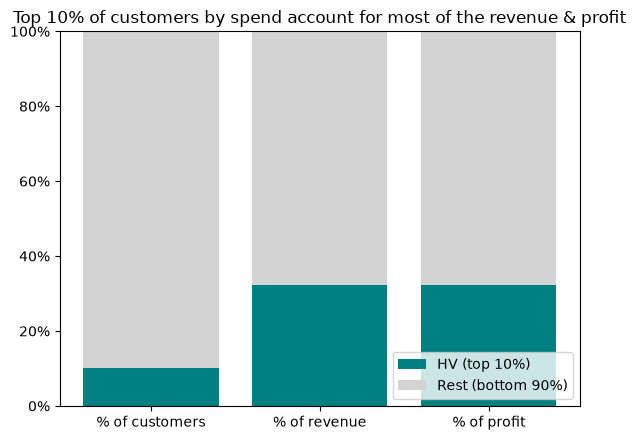

In [24]:
fig, ax = plt.subplots(figsize=(6, 4.5))
metrics = ["% of customers", "% of revenue", "% of profit"]
hv_vals = [pareto.loc["HV (top 10%)", m] for m in metrics]
rest_vals = [pareto.loc["Rest (bottom 90%)", m] for m in metrics]

ax.bar(metrics, hv_vals, label="HV (top 10%)", color="teal")
ax.bar(metrics, rest_vals, bottom=hv_vals, label="Rest (bottom 90%)", color="lightgray")
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0, 100)
ax.set_title("Top 10% of customers by spend account for most of the revenue & profit")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**Conflict:** a fixed 10% of customers is never going to drive an even share of revenue —
some concentration is mechanical. The interesting question is *how much* concentration, and
whether it's even more skewed on profit than on revenue (i.e. whether HV customers are also
disproportionately the profitable ones, not just the big ones).

## 2. Where do HV customers come from?

Compare the country mix of HV customers against the overall customer base. A country that's
over-represented among HV customers (relative to its overall share) is worth flagging for
targeted marketing / account management; one that's under-represented despite high order
volume is a conversion opportunity.

In [25]:
hv = cust[cust["segment"] == "HV (top 10%)"]
rest = cust[cust["segment"] == "Rest (bottom 90%)"]

country_all = cust["country"].value_counts(normalize=True).mul(100)
country_hv = hv["country"].value_counts(normalize=True).mul(100)

top_countries = country_all.head(10).index
comp = pd.DataFrame({
    "All customers %": country_all.reindex(top_countries),
    "HV customers %": country_hv.reindex(top_countries),
}).fillna(0)
comp["index (HV / all)"] = (comp["HV customers %"] / comp["All customers %"]).round(2)
comp.round(1)

,All customers %,HV customers %,index (HV / all)
country,,,
DE,22.3,29.1,1.3
SE,16.4,10.4,0.6
GB,11.4,9.5,0.8
DK,7.6,7.0,0.9
NL,7.5,5.9,0.8
FR,6.3,6.3,1.0
PL,5.4,3.1,0.6
NO,4.5,3.7,0.8
FI,3.4,1.8,0.5


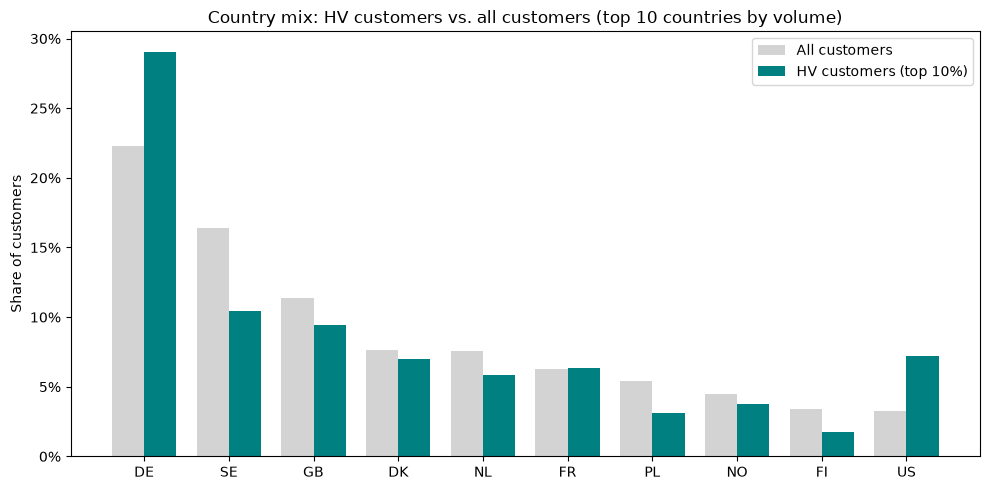

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(top_countries))
width = 0.38

ax.bar(x - width / 2, comp["All customers %"], width, label="All customers", color="lightgray")
ax.bar(x + width / 2, comp["HV customers %"], width, label="HV customers (top 10%)", color="teal")

ax.set_xticks(x)
ax.set_xticklabels(top_countries)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Share of customers")
ax.set_title("Country mix: HV customers vs. all customers (top 10 countries by volume)")
ax.legend()
fig.tight_layout()
plt.show()

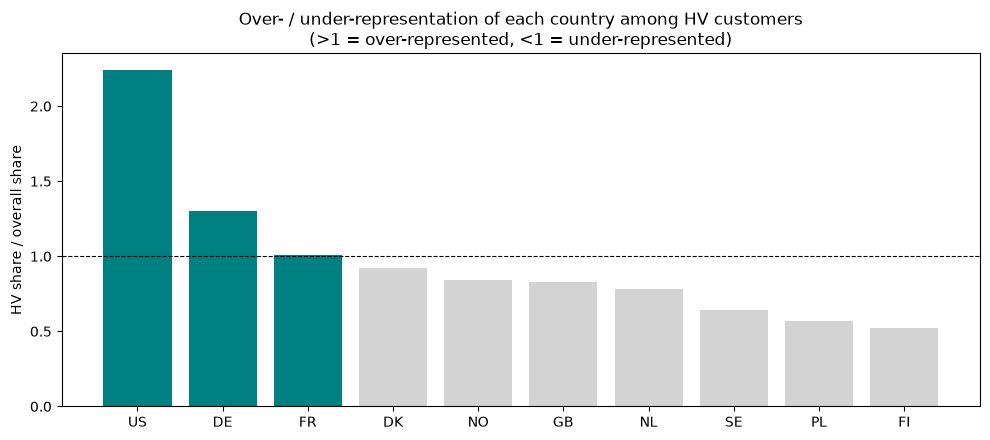

In [27]:
fig, ax = plt.subplots(figsize=(10, 4.5))
idx = comp["index (HV / all)"].sort_values(ascending=False)
colors = ["teal" if v >= 1 else "lightgray" for v in idx.values]
ax.bar(idx.index, idx.values, color=colors)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("HV share / overall share")
ax.set_title("Over- / under-representation of each country among HV customers\n(>1 = over-represented, <1 = under-represented)")
fig.tight_layout()
plt.show()

## 2b. How much more is an HV customer actually worth?

Two comparisons: HV vs. the **global** average customer, and HV vs. the average customer **in
their own country** — the second controls for the fact that some countries just have
richer/bigger-basket customers overall, so it isolates the HV effect from a country effect.

In [28]:
overall_avg_spend = cust["total_spend"].mean()
overall_avg_profit = cust["total_profit"].mean()
hv_avg_spend = hv["total_spend"].mean()
hv_avg_profit = hv["total_profit"].mean()

spend_multiple = hv_avg_spend / overall_avg_spend
profit_multiple = hv_avg_profit / overall_avg_profit

print(f"Avg lifetime spend  — HV: {hv_avg_spend:,.0f} | All customers: {overall_avg_spend:,.0f} | HV is {spend_multiple:.1f}x the average customer")
print(f"Avg lifetime profit — HV: {hv_avg_profit:,.0f} | All customers: {overall_avg_profit:,.0f} | HV is {profit_multiple:.1f}x the average customer")

Avg lifetime spend  — HV: 1,954 | All customers: 603 | HV is 3.2x the average customer
Avg lifetime profit — HV: 1,224 | All customers: 378 | HV is 3.2x the average customer


In [29]:
country_avg = cust.groupby("country").agg(
    country_avg_spend=("total_spend", "mean"),
    country_avg_profit=("total_profit", "mean"),
    n_customers=("total_spend", "size"),
)
hv_country_avg = hv.groupby("country").agg(
    hv_avg_spend=("total_spend", "mean"),
    hv_avg_profit=("total_profit", "mean"),
)

country_value = country_avg.join(hv_country_avg).loc[top_countries]
country_value["HV vs. country avg (spend)"] = country_value["hv_avg_spend"] / country_value["country_avg_spend"]
country_value["HV vs. country avg (profit)"] = country_value["hv_avg_profit"] / country_value["country_avg_profit"]
country_value = country_value.sort_values("HV vs. country avg (spend)", ascending=False)
country_value[["country_avg_spend", "hv_avg_spend", "HV vs. country avg (spend)", "HV vs. country avg (profit)"]].round(1)

,country_avg_spend,hv_avg_spend,HV vs. country avg (spend),HV vs. country avg (profit)
country,,,,
PL,495.2,1868.6,3.8,3.7
SE,505.5,1861.8,3.7,3.7
FI,501.9,1792.7,3.6,3.6
GB,551.4,1929.7,3.5,3.5
NL,537.1,1848.5,3.4,3.4
DK,590.8,1936.0,3.3,3.3
NO,568.6,1821.7,3.2,3.2
FR,605.6,1909.5,3.2,3.2
DE,681.1,1931.9,2.8,2.9


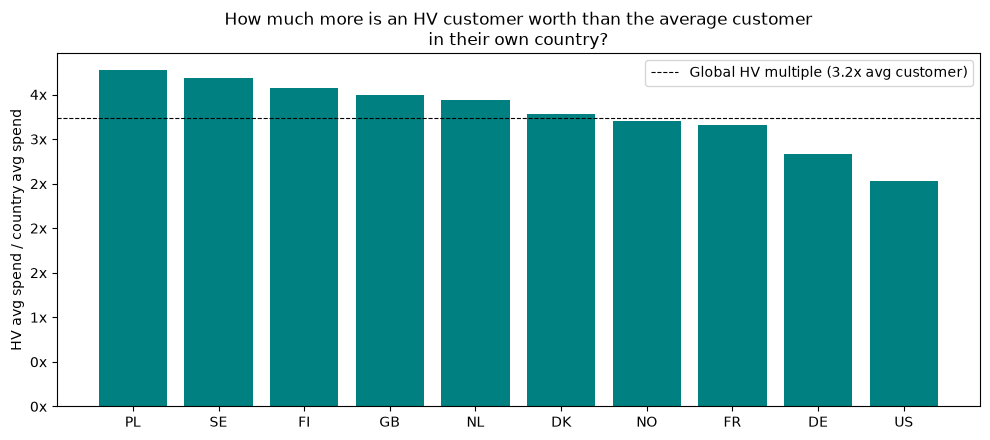

In [30]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(country_value))
ax.bar(x, country_value["HV vs. country avg (spend)"], color="teal")
ax.axhline(spend_multiple, color="black", linewidth=0.8, linestyle="--",
           label=f"Global HV multiple ({spend_multiple:.1f}x avg customer)")
ax.set_xticks(x)
ax.set_xticklabels(country_value.index)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:.0f}x"))
ax.set_ylabel("HV avg spend / country avg spend")
ax.set_title("How much more is an HV customer worth than the average customer\nin their own country?")
ax.legend()
fig.tight_layout()
plt.show()

## 3. How much do HV customers order?

Two ways a customer becomes "high value": ordering **often** (volume) or ordering **big**
(ticket size). We check both, plus how long they stay active (lifetime span between first and
last order).

In [31]:
order_stats = cust.groupby("segment").agg(
    median_n_orders=("n_orders", "median"),
    mean_n_orders=("n_orders", "mean"),
    median_aov=("avg_order_value", "median"),
    mean_aov=("avg_order_value", "mean"),
    median_lifetime_days=("lifetime_days", "median"),
    mean_lifetime_days=("lifetime_days", "mean"),
).round(1)
order_stats

,median_n_orders,mean_n_orders,median_aov,mean_aov,median_lifetime_days,mean_lifetime_days
segment,,,,,,
HV (top 10%),1.0,1.7,1284.5,1359.6,0.0,57.3
Rest (bottom 90%),1.0,1.1,368.8,414.4,0.0,12.8


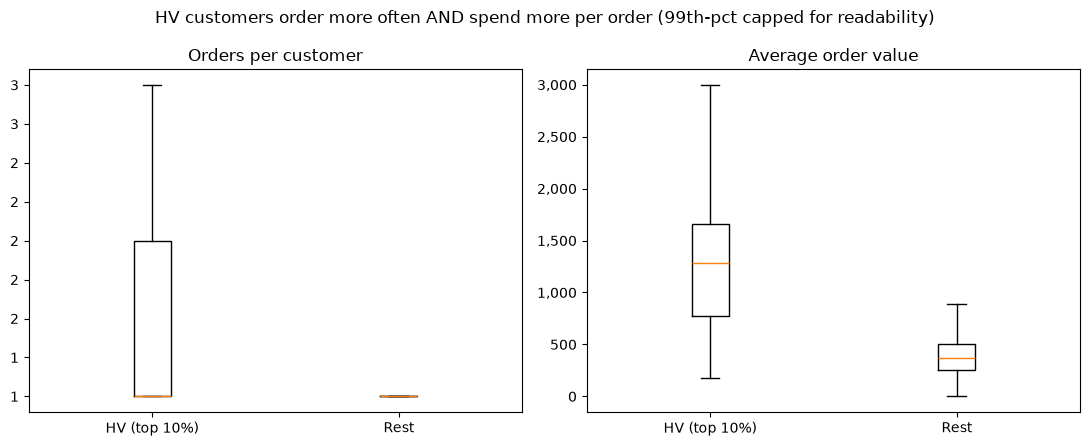

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, col, title in zip(
    axes,
    ["n_orders", "avg_order_value"],
    ["Orders per customer", "Average order value"],
):
    data = [hv[col].clip(upper=hv[col].quantile(0.99)), rest[col].clip(upper=hv[col].quantile(0.99))]
    ax.boxplot(data, tick_labels=["HV (top 10%)", "Rest"], showfliers=False)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(PLAIN)

fig.suptitle("HV customers order more often AND spend more per order (99th-pct capped for readability)")
fig.tight_layout()
plt.show()

## 4. When do HV customers order?

Compare the time-of-day and day-of-week order distribution for HV vs. the rest. Since group
sizes differ hugely, we compare using **order shares within each group** (density), not raw
counts.

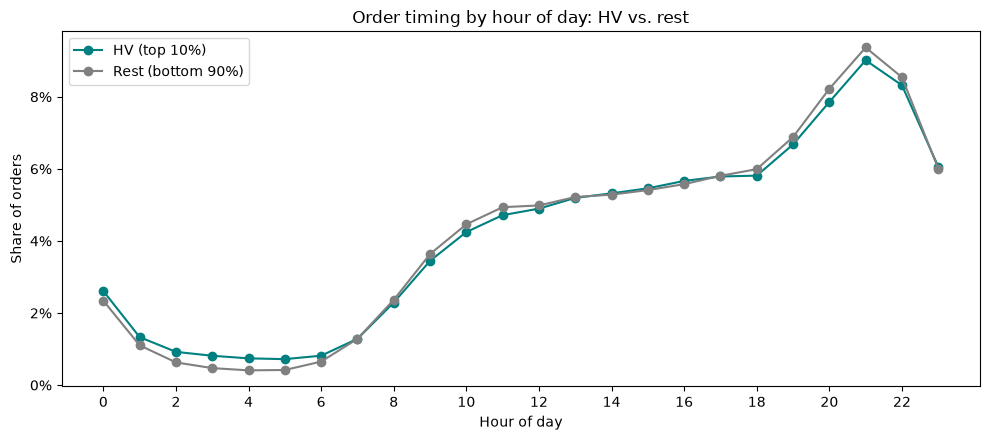

In [33]:
orders_hv = df[df["Customer_iD"].isin(hv.index)]
orders_rest = df[df["Customer_iD"].isin(rest.index)]

hour_hv = orders_hv["hour"].value_counts(normalize=True).sort_index() * 100
hour_rest = orders_rest["hour"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(hour_hv.index, hour_hv.values, marker="o", color="teal", label="HV (top 10%)")
ax.plot(hour_rest.index, hour_rest.values, marker="o", color="gray", label="Rest (bottom 90%)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Share of orders")
ax.yaxis.set_major_formatter(PCT)
ax.set_xticks(range(0, 24, 2))
ax.set_title("Order timing by hour of day: HV vs. rest")
ax.legend()
fig.tight_layout()
plt.show()

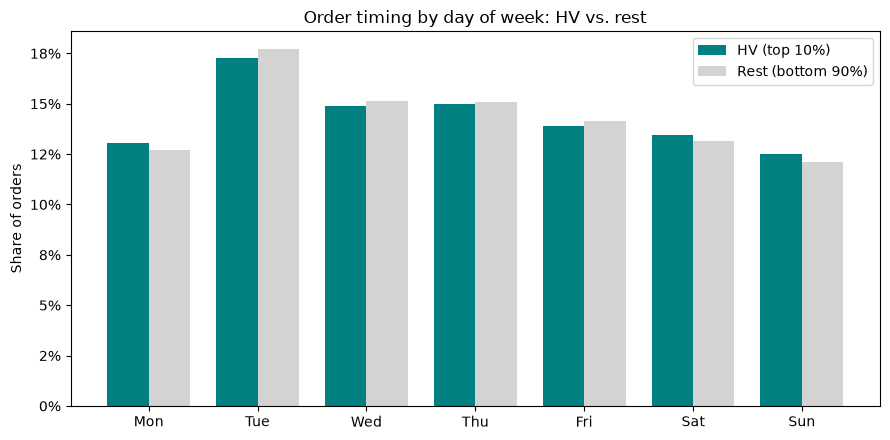

In [34]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_hv = orders_hv["dow"].value_counts(normalize=True).reindex(dow_order) * 100
dow_rest = orders_rest["dow"].value_counts(normalize=True).reindex(dow_order) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(dow_order))
width = 0.38
ax.bar(x - width / 2, dow_hv.values, width, label="HV (top 10%)", color="teal")
ax.bar(x + width / 2, dow_rest.values, width, label="Rest (bottom 90%)", color="lightgray")
ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in dow_order])
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Share of orders")
ax.set_title("Order timing by day of week: HV vs. rest")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Profit margin — bigger spenders, or genuinely more profitable orders?

`Profit_margin` is recorded per order. We compare the average margin HV customers get vs. the
rest, both simple mean-of-orders and the "true" blended margin (`total_profit / total_spend`) to
make sure a few outlier orders aren't skewing a plain average.

In [35]:
margin_simple = df.groupby(df["Customer_iD"].isin(hv.index))["Profit_margin"].mean()
margin_simple.index = margin_simple.index.map({True: "HV (top 10%)", False: "Rest (bottom 90%)"})

blended = cust.groupby("segment").apply(
    lambda g: g["total_profit"].sum() / g["total_spend"].sum(), include_groups=False
)

margin_comp = pd.DataFrame({
    "Mean order-level margin": margin_simple,
    "Blended margin (profit / spend)": blended,
}).round(3) * 100
margin_comp = margin_comp.round(1)
margin_comp.columns = [c + " (%)" for c in margin_comp.columns]
margin_comp

,Mean order-level margin (%),Blended margin (profit / spend) (%)
HV (top 10%),64.1,62.7
Rest (bottom 90%),64.2,62.6


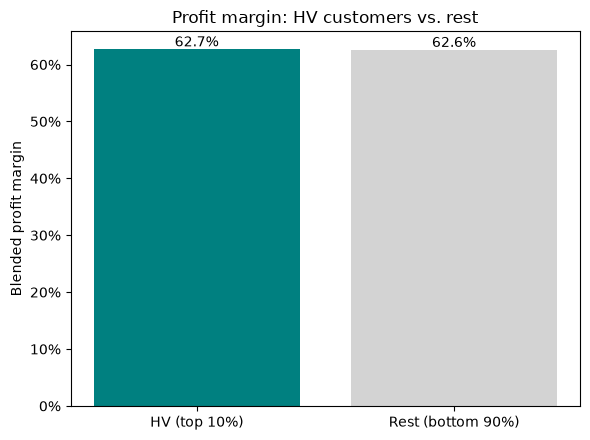

In [36]:
fig, ax = plt.subplots(figsize=(6, 4.5))
segments = ["HV (top 10%)", "Rest (bottom 90%)"]
vals = [margin_comp.loc[s, "Blended margin (profit / spend) (%)"] for s in segments]
ax.bar(segments, vals, color=["teal", "lightgray"])
ax.yaxis.set_major_formatter(PCT)
ax.set_ylabel("Blended profit margin")
ax.set_title("Profit margin: HV customers vs. rest")
for i, v in enumerate(vals):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
fig.tight_layout()
plt.show()

## 6. Which high-GDP countries should have more HV customers — and don't?

"Buying power" is proxied by GDP per capita, PPP (current international $), fetched live from
the World Bank API for 2019 (same method as `orders_eda.ipynb`). Source:
[World Bank, indicator NY.GDP.PCAP.PP.CD](https://data.worldbank.org/indicator/NY.GDP.PCAP.PP.CD).

We compute each country's **HV rate**: the share of *its own* customers who reach HV status
(not the headcount-share view from section 2). If wealthier countries simply convert more of
their customers to HV, GDP and HV rate should move together — a linear fit gives the "expected"
HV rate for a country's GDP level. The residual (actual − expected) flags countries that
over- or under-perform what their wealth alone would predict.

Caveat: the HV threshold (~1,202) is one **global absolute cutoff**, not adjusted for local
price levels or income — so lower-GDP countries are mechanically disadvantaged at clearing it.
The linear fit already bakes that baseline relationship in; what's interesting is who deviates
from *it*, not from a flat line.

In [37]:
import json
import urllib.request

iso3 = {
    "DE": "DEU", "SE": "SWE", "GB": "GBR", "DK": "DNK", "NL": "NLD",
    "FR": "FRA", "PL": "POL", "NO": "NOR", "FI": "FIN", "US": "USA",
}
codes = [iso3[c] for c in top_countries if c in iso3]
url = (
    "https://api.worldbank.org/v2/country/" + ";".join(codes)
    + "/indicator/NY.GDP.PCAP.PP.CD?date=2019&format=json&per_page=100"
)

with urllib.request.urlopen(url, timeout=15) as resp:
    payload = json.load(resp)

gdp_ppp = pd.Series(
    {rec["country"]["id"]: rec["value"] for rec in payload[1]},
    name="gdp_per_capita_ppp_2019",
)
gdp_ppp.round(0)

DE    59311.0
DK    60595.0
FI    52276.0
FR    51130.0
GB    50494.0
NL    62345.0
NO    73630.0
PL    35882.0
SE    56910.0
US    65228.0
Name: gdp_per_capita_ppp_2019, dtype: float64

In [38]:
hv_rate = cust.groupby("country").apply(
    lambda g: (g["segment"] == "HV (top 10%)").mean() * 100, include_groups=False
)
hv_rate.name = "hv_rate_pct"

gdp_vs_hv = pd.DataFrame({
    "gdp_per_capita_ppp_2019": gdp_ppp,
    "hv_rate_pct": hv_rate.reindex(gdp_ppp.index),
}).dropna()

slope, intercept = np.polyfit(gdp_vs_hv["gdp_per_capita_ppp_2019"], gdp_vs_hv["hv_rate_pct"], 1)
gdp_vs_hv["expected_hv_rate_pct"] = slope * gdp_vs_hv["gdp_per_capita_ppp_2019"] + intercept
gdp_vs_hv["residual_pp"] = gdp_vs_hv["hv_rate_pct"] - gdp_vs_hv["expected_hv_rate_pct"]
gdp_vs_hv.sort_values("residual_pp", ascending=False).round(2)

,gdp_per_capita_ppp_2019,hv_rate_pct,expected_hv_rate_pct,residual_pp
US,65227.96,22.39,11.36,11.03
DE,59310.97,13.04,10.16,2.88
FR,51130.47,10.10,8.50,1.60
PL,35882.37,5.73,5.40,0.32
GB,50493.94,8.29,8.37,-0.08
DK,60594.97,9.17,10.42,-1.25
NL,62345.25,7.79,10.78,-2.99
SE,56909.75,6.36,9.67,-3.31
FI,52276.11,5.22,8.73,-3.51
NO,73630.07,8.38,13.07,-4.69


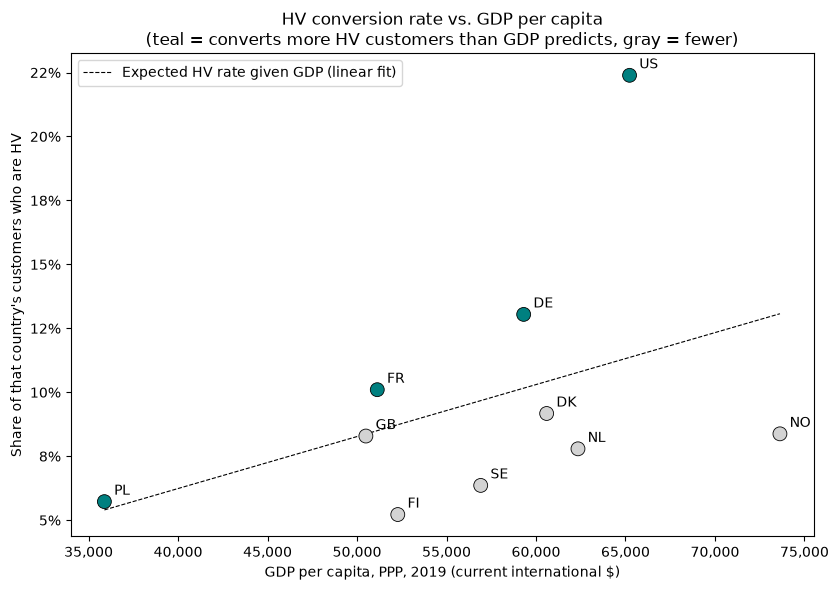

In [39]:
fig, ax = plt.subplots(figsize=(8.5, 6))
colors = ["teal" if r >= 0 else "lightgray" for r in gdp_vs_hv["residual_pp"]]
ax.scatter(
    gdp_vs_hv["gdp_per_capita_ppp_2019"], gdp_vs_hv["hv_rate_pct"],
    s=100, c=colors, edgecolors="black", linewidths=0.6, zorder=3,
)

xs = np.linspace(gdp_vs_hv["gdp_per_capita_ppp_2019"].min(), gdp_vs_hv["gdp_per_capita_ppp_2019"].max(), 50)
ax.plot(xs, slope * xs + intercept, color="black", linestyle="--", linewidth=0.8,
        label="Expected HV rate given GDP (linear fit)")

for country, row in gdp_vs_hv.iterrows():
    ax.annotate(country, (row["gdp_per_capita_ppp_2019"], row["hv_rate_pct"]),
                textcoords="offset points", xytext=(7, 5))

ax.set_xlabel("GDP per capita, PPP, 2019 (current international $)")
ax.set_ylabel("Share of that country's customers who are HV")
ax.xaxis.set_major_formatter(PLAIN)
ax.yaxis.set_major_formatter(PCT)
ax.set_title("HV conversion rate vs. GDP per capita\n(teal = converts more HV customers than GDP predicts, gray = fewer)")
ax.legend()
fig.tight_layout()
plt.show()

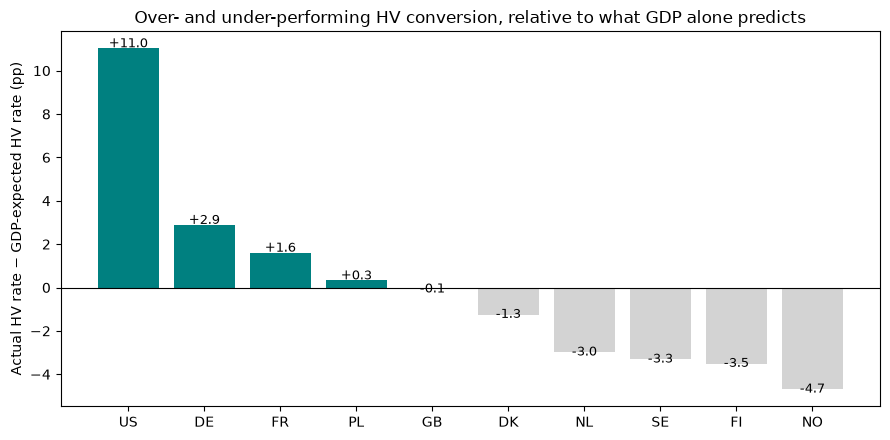

In [40]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ranked = gdp_vs_hv["residual_pp"].sort_values(ascending=False)
colors = ["teal" if v >= 0 else "lightgray" for v in ranked.values]
ax.bar(ranked.index, ranked.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Actual HV rate − GDP-expected HV rate (pp)")
ax.set_title("Over- and under-performing HV conversion, relative to what GDP alone predicts")
for i, v in enumerate(ranked.values):
    ax.text(i, v + (0.05 if v >= 0 else -0.15), f"{v:+.1f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

**Finding:** GDP alone is a weak predictor here — a handful of wealthy markets clearly
under-convert relative to what their GDP implies:

- **Norway is the standout gap.** It has the *highest* GDP per capita of the group (73,630) but
  only an 8.4% HV rate — the fit predicts 13.1% given that wealth, a **-4.7pp** shortfall, the
  largest in either direction.
- **Finland, Sweden and the Netherlands** are all wealthy (GDP 52k-62k, in the upper half of the
  group) but under-convert by **-3.0 to -3.5pp** each. Denmark is a smaller, similar-direction
  miss (-1.3pp).
- **The US is the opposite extreme** — already the group's #2 GDP, yet its HV rate (22.4%) is
  roughly **double** what the fit expects (11.4%), a **+11.0pp** gap dwarfing every other
  country's deviation in either direction.
- **DE and FR modestly over-convert** (+2.9pp, +1.6pp); **PL over-converts slightly** (+0.3pp)
  despite having by far the lowest GDP in the group; **GB sits almost exactly on the line**
  (-0.1pp).

So the countries that "should" have more HV customers given their wealth and don't are a
**Nordic-plus-Netherlands cluster: Norway, Finland, Sweden, Denmark, and the Netherlands** —
not the low-GDP markets you might expect to be under-indexed. The US is the one clear outlier
converting far more of its customer base to HV than income alone would explain.

## Summary

**Setup:** are the top 10% of customers by spend a distinct, targetable segment, or just a
statistical artifact of ranking?

**Conflict:** they're a real segment, but not for the reason you might expect:

- **Concentration:** the top 10% of customers account for 32.4% of revenue *and* 32.4% of
  profit — the two shares match to a decimal point.
- **Worth vs. the average customer:** an HV customer is worth **3.2x** the average customer on
  both lifetime spend (1,954 vs. 603) and lifetime profit (1,224 vs. 378) — the multiple is
  identical on spend and profit because margin doesn't differ by segment (see below).
- **Worth vs. the average customer in their own country:** the multiple isn't uniform once you
  control for country. PL, SE and FI — the markets that looked *under*-represented by HV
  *headcount* — actually have the **highest** within-country multiples (3.6-3.8x): an HV customer
  there is a bigger leap above their local peers than anywhere else. The US and DE, which were
  *over*-represented by headcount, have the **lowest** multiples (2.5x and 2.8x) — mainly because
  their overall country averages are already higher (953 and 681 vs. ~500-600 elsewhere), so
  reaching HV status there is a smaller relative jump. In other words: the US/DE produce *more*
  HV customers per capita, but PL/SE/FI's HV customers are *more exceptional* relative to their
  own market.
- **Geography (headcount):** DE is both the largest market and modestly over-represented among
  HV customers (1.3x its overall customer share). The US stands out sharply — only 3.2% of all
  customers, but 7.2% of HV customers (2.2x over-indexed). SE, PL and FI are large customer bases
  (16%, 5%, 3% of all customers) but noticeably under-indexed among HV (0.5-0.6x) — big volume,
  smaller baskets.
- **GDP doesn't explain who over/under-converts.** Regressing each country's HV rate (share of
  its own customers reaching HV) on GDP per capita (PPP) shows the wealthiest Nordic markets —
  **Norway, Finland, Sweden, Denmark, and the Netherlands** — all convert *fewer* customers to
  HV than their income would predict (Norway is the single biggest miss: highest GDP in the
  group, -4.7pp below its GDP-implied HV rate). The **US** is the mirror-image outlier,
  converting roughly double the HV rate its GDP predicts (+11.0pp) — by far the largest
  deviation of any country in either direction. DE and FR modestly over-convert; PL slightly
  over-converts despite the lowest GDP in the group; GB sits almost exactly on the GDP-implied
  line.
- **How they order:** the *median* customer — HV or not — places exactly **1 order**. HV status
  is driven almost entirely by **order size, not frequency**: median AOV is 1,285 for HV vs. 369
  for the rest (3.5x), while order counts are close (mean 1.7 vs. 1.1). HV customers do have a
  much longer mean active lifetime (57 vs. 13 days), but that's a mean pulled up by a repeat-buyer
  tail, not the typical case.
- **Timing:** essentially no difference. Both segments peak at 21:00 and follow the same weekday
  pattern (Tue > Thu/Wed > Fri > Mon/Sat > Sun); the largest hour-level gap is under 0.4
  percentage points. There's no HV-specific "golden hour."
- **Margin:** virtually identical — ~64% mean order-level margin and ~62.6-62.7% blended margin
  for both segments. HV customers are not more profitable *per order*; they're the same margin at
  a bigger basket size, which is exactly why their revenue and profit shares (and spend/profit
  multiples) are identical.

**Resolution:** high-value status here is a **basket-size story, not a loyalty or timing story**,
and the geographic picture only gets clearer by layering headcount share, within-country value,
and GDP together:

1. **No margin lever needed.** Since profit share tracks revenue share 1:1, growing HV revenue
   grows profit at the same rate — there's no hidden margin upside or downside to underwrite
   first.
2. **The acquisition/growth lever is basket-building, not retention or scheduling.** Because HV
   customers mostly aren't repeat buyers with more orders — they're one-time (or near one-time)
   buyers with bigger carts — tactics should focus on raising AOV (bundling, cross-sell,
   minimum-order incentives) rather than order-frequency campaigns or time-of-day targeting,
   which show no signal here.
3. **Norway, Finland, Sweden, Denmark and the Netherlands are the clearest opportunity markets.**
   They're wealthy enough to support more HV customers than they currently produce (GDP predicts
   it), their existing HV customers are already worth 3.2-3.6x the local average once they do
   convert, and yet their headcount conversion trails what income alone would suggest — the gap
   isn't a wealth problem, it's a conversion problem (product mix, assortment, pricing, or
   marketing worth investigating).
4. **The US is the template worth studying, not just praising.** It over-converts on GDP (+11pp,
   by far the largest gap either direction) *and* under-indexes on the within-country value
   multiple (2.5x, the lowest of the group) — meaning the US doesn't get outsized value from
   each HV customer, it simply creates far more of them relative to its income level than any
   other market. Understanding what US customers/marketing/assortment does differently to clear
   the HV bar so much more often is likely the single highest-leverage question raised by this
   analysis.